In [1]:
import pandas as pd

In [2]:
car_sales_df = pd.read_csv(
    "C:/Users/idan8/Downloads/Car Sales.xlsx - car_data.csv/Car Sales.xlsx - car_data.csv"
)

## 2.2 Description of the Data Source

### Data Source

- I downloaded the dataset from Kaggle.
- It contains information about car sales, including customer details, car information, sale price, sale date, dealership, and region.

---

### Purpose of Data Collection

- **Market analysis:** The dataset can be used to study car sales and compare different regions, models, and customer groups.

- **Seasonal analysis and competitor comparison:** It can help identify months with higher or lower sales and also compare different companies, models, and dealerships.

- **Forecasting and predictive analysis:** Previous sales data can be used to look for trends and may help with future marketing and business decisions.

- **Supply chain and inventory optimization:** The data can also help dealerships see which cars are more popular and plan their inventory according to demand.

---

### Data Publisher

- The dataset was uploaded to Kaggle by a student named Vasu Avasthi.
- The dataset does not clearly state who collected the original data.

---

### Personal Background

- I have some basic knowledge about cars, and my family often asks me for advice when they are choosing a car.

## 3. Meta-Analysis of the Dataset

### 3.1 File Analysis

In [3]:
#File size

import os

file_path = "C:/Users/idan8/Downloads/Car Sales.xlsx - car_data.csv/Car Sales.xlsx - car_data.csv"

file_size_mb = os.path.getsize(file_path) / (1024 ** 2)

print(f"File size: {file_size_mb:.2f} MB")


File size: 3.66 MB


## 3. Meta-Analysis of the Dataset

### 3.1 File Analysis

### File Size

- The file size is 3.66 MB.

---

### File Format

- The dataset is stored in CSV format.

---

### Purpose of the Dataset

The dataset can be used to analyze the vehicle sales market, including:

- Sales trends.
- Customer preferences.
- Differences between manufacturers and regions.
- Inventory forecasting.
- Inventory planning.

---

## 3. Meta-Analysis of the Dataset

### 3.2 Data Structure

In [4]:
car_sales_df.shape

(23906, 16)

In [5]:
car_sales_df.columns.tolist()

['Car_id',
 'Date',
 'Customer Name',
 'Gender',
 'Annual Income',
 'Dealer_Name',
 'Company',
 'Model',
 'Engine',
 'Transmission',
 'Color',
 'Price ($)',
 'Dealer_No ',
 'Body Style',
 'Phone',
 'Dealer_Region']

In [6]:
car_sales_df.dtypes

Car_id           object
Date             object
Customer Name    object
Gender           object
Annual Income     int64
Dealer_Name      object
Company          object
Model            object
Engine           object
Transmission     object
Color            object
Price ($)         int64
Dealer_No        object
Body Style       object
Phone             int64
Dealer_Region    object
dtype: object

### 3.2 Data Structure

### Number of Rows and Columns

The dataset has **23,906 rows** and **16 columns**. Each row represents one car sale, and each column gives different information about the customer, the car, the sale, or the dealership.

---

### Column Names

I divided the columns into four main groups:

1. **Transaction details:** `Car_id`, `Date`, `Price ($)`
2. **Customer details:** `Customer Name`, `Gender`, `Annual Income`, `Phone`
3. **Vehicle details:** `Company`, `Model`, `Engine`, `Transmission`, `Color`, `Body Style`
4. **Dealership details:** `Dealer_Name`, `Dealer_No`, `Dealer_Region`

---

### Data Types

`Annual Income` and `Price ($)` are stored as `int64`. This makes sense because both of them are numerical values and can be used in calculations.

`Date` is stored as an `object`, even though it represents a date. Later in the analysis, it should be changed to `datetime`.

`Phone` is also stored as `int64`, but it should not really be treated as a numerical variable. For example, calculating an average phone number would not give any useful information. It is better to treat this column as an identifier or as text.

`Car_id` and `Dealer_No` are also identifiers, so they should not be used like normal numerical variables.

Most of the `object` columns, such as `Gender`, `Company`, `Model`, `Engine`, `Transmission`, `Color`, `Body Style`, and `Dealer_Region`, contain categorical or text information.

---

### Data Collection Purpose

From the columns in the dataset, it looks like the data may have been collected mainly to keep records of car sales, customers, dealerships, prices, and sale dates.

For example, the dataset includes customer names and phone numbers, car IDs, dealership information, prices, and dates.

The original reason for collecting the data is not clearly given, so this is only my assumption based on the columns that appear in the dataset.

---

### Possible Biases and Limitations

There are a few possible limitations in the dataset.

The data may come only from certain dealerships or regions, so it might not represent the whole car market.

It also covers a limited period of time, which can affect the results.

The number of customers from different genders or income levels may also not be balanced compared to the general population.

There may also be problems such as data entry mistakes, duplicate records, or missing values.

Some useful information is not included, such as customer age, car condition, discounts, financing, and mileage. Because of this, there are some questions that cannot be fully answered with this dataset alone.

## 4. Data Quality and Completeness

### 4.1 Missing Data

In [7]:
missing_values = car_sales_df.isna().sum()
missing_values

Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64

In [8]:
car_sales_df[car_sales_df["Customer Name"].isna()]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
7564,C_CND_007565,11/5/2022,NaN,Male,680000,Saab-Belle Dodge,Dodge,Ram Pickup,DoubleÂ Overhead Camshaft,Auto,Pale White,45000,60504-7114,Hardtop,7203103,Aurora


### 4.1 Missing Data

### Amount of Missing Data

I found only one missing value in the whole dataset, and it is in the `Customer Name` column. All the other columns are complete. This missing value is only about **0.0042%** of the records in this column, so the amount of missing data is very small.

---

### Missing Data Pattern

The only missing value appears in `Customer Name`. The rest of the information in that row is complete. I also did not find any clear connection between this missing value and the date, dealership, region, car details, or customer details. Because of this, it seems that the missing value is random.

---

### Conclusion

Since there is only one missing value, there is not enough information to find a real pattern or draw any general conclusion from it.

---

### Handling the Missing Value

The missing name can be replaced with a random female name.

## 4. Data Quality and Completeness

### 4.2 Duplicates

In [9]:
full_duplicates = car_sales_df.duplicated().sum()
full_duplicates

np.int64(0)

In [10]:
columns_to_check = car_sales_df.columns.drop("Car_id")

partial_duplicates = car_sales_df.duplicated(
    subset=columns_to_check,
    keep=False
)

partial_duplicates.sum()

np.int64(0)

### 4.2 Duplicates

### Full Duplicates

- I did not find any full duplicates in the dataset. This means there are no rows that are exactly the same in all 16 columns.

---

### Partial Duplicates

- I also checked for partial duplicates by comparing all the columns except `Car_id`. I wanted to see if the same sale appeared more than once but with a different ID. I did not find any rows with the same details, so no partial duplicates were found in this check.

---

### Can Anything Be Inferred from the Duplicates?

- Since I did not find full duplicates or partial duplicates, there is no clear sign that the same transaction was entered more than once.

---

### Should the Duplicates Be Removed or Should Another Method Be Used?

- Because no suspicious duplicates were found, there is no reason to remove any rows. Removing rows without a clear reason could delete valid data.

## 4. Data Quality and Completeness

### 4.3 Suspicious values

In [11]:
categorical_columns = [
    "Gender",
    "Engine",
    "Transmission",
    "Color",
    "Body Style",
    "Dealer_Region"
]

for column in categorical_columns:
    print(f"{column}:")
    print(car_sales_df[column].unique())
    print()

Gender:
['Male' 'Female']

Engine:
['DoubleÂ\xa0Overhead Camshaft' 'Overhead Camshaft']

Transmission:
['Auto' 'Manual']

Color:
['Black' 'Red' 'Pale White']

Body Style:
['SUV' 'Passenger' 'Hatchback' 'Hardtop' 'Sedan']

Dealer_Region:
['Middletown' 'Aurora' 'Greenville' 'Pasco' 'Janesville' 'Scottsdale'
 'Austin']



In [12]:
placeholder_values = [
    "unknown",
    "n/a",
    "na",
    "none",
    "null",
    "-",
    "not available"
]

for column in car_sales_df.select_dtypes(include="object").columns:
    normalized_values = car_sales_df[column].astype(str).str.strip().str.lower()

    placeholder_count = normalized_values.isin(placeholder_values).sum()

    if placeholder_count > 0:
        print(f"{column}: {placeholder_count}")

In [13]:
numeric_columns = car_sales_df.select_dtypes(include="number").columns

for column in numeric_columns:
    zero_count = (car_sales_df[column] == 0).sum()
    negative_count = (car_sales_df[column] < 0).sum()

    print(f"{column}:")
    print(f"Zero values: {zero_count}")
    print(f"Negative values: {negative_count}")
    print()

Annual Income:
Zero values: 0
Negative values: 0

Price ($):
Zero values: 0
Negative values: 0

Phone:
Zero values: 0
Negative values: 0



### 4.3 Suspicious Values

### Impossible Values

- When checking the unique values in the categorical columns, no logically impossible values were found. The values in the gender, transmission, color, body style, and dealership region columns seem reasonable.
  However, in the `Engine` column, the value `DoubleÂ\xa0Overhead Camshaft` was found. This most likely indicates a text encoding problem and not a real separate category. The value is probably supposed to be `Double Overhead Camshaft`, so it will need to be cleaned later.

---

### Placeholder Values

- No common placeholder values were found in the dataset, such as `Unknown`, `N/A`, `NA`, `None`, `Null`, `-`, or `Not Available`.

---

### Unreasonable Zeros or Negative Numbers

- No zero or negative values were found in the numerical columns `Annual Income`, `Price ($)`, and `Phone`. This result makes sense because annual income and sale price are not expected to be negative, and a price or income value of zero could indicate a missing value or a data entry error.

---

### Do These Values Tell Us Anything About the Data?

- No unreasonable zero or negative values were found in the numerical columns. This may indicate that the data probably went through basic checks or was collected under restrictions that prevented these values from being entered.

## 4. Data Quality and Completeness

### 4.4 Cardinalities

In [14]:
unique_values_per_column = car_sales_df.nunique(dropna=False)

single_value_columns = unique_values_per_column[
    unique_values_per_column == 1
]

single_value_columns

Series([], dtype: int64)

In [15]:
unique_values_per_column = car_sales_df.nunique(dropna=False)

unique_values_per_column.sort_values(ascending=False)

Car_id           23906
Phone            23804
Customer Name     3022
Annual Income     2508
Price ($)          870
Date               612
Model              154
Company             30
Dealer_Name         28
Dealer_No            7
Dealer_Region        7
Body Style           5
Color                3
Gender               2
Engine               2
Transmission         2
dtype: int64

### 4.4 Cardinality

### Columns Without Variance: Are There Columns With a Single Value?

- I did not find any column that has the same value in every row.
- This means that all the columns have some variation.
- Because of this, there is no column that needs to be removed just because all of its values are the same.

---

### Columns With Many Unique Values

- Some columns have a large number of unique values.

- `Car_id` has **23,906 unique values**, so each row has its own ID.

- `Phone` has **23,804 unique values**. Most phone numbers appear only once, but a few appear in more than one row.

- `Customer Name` has **3,022 unique values**, so some names appear several times. This does not always mean that it is the same customer.

- On the other hand, columns like `Gender`, `Engine`, and `Transmission` have only two possible values, so their cardinality is low.

- Columns such as `Car_id` and `Phone` have very high cardinality and are mainly used as identifiers, so they are usually not useful as regular categorical variables in statistical analysis or models.

## 5. Univariate analysis

### 5.1 Numeric variables

In [16]:
from plotnine import ggplot, aes, geom_histogram, labs

In [17]:
import matplotlib.pyplot as plt

# Calculate the mean values
mean_annual_income = car_sales_df["Annual Income"].mean()
mean_car_price = car_sales_df["Price ($)"].mean()

print(f"Mean Annual Income: ${mean_annual_income:,.2f}")
print(f"Mean Car Price: ${mean_car_price:,.2f}")

Mean Annual Income: $830,840.29
Mean Car Price: $28,090.25


In [18]:
# Calculate the median of the relevant numerical columns
car_sales_df[["Annual Income", "Price ($)"]].median()

Annual Income    735000.0
Price ($)         23000.0
dtype: float64

In [19]:
# Calculate the standard deviation of the relevant numerical columns
car_sales_df[["Annual Income", "Price ($)"]].std()

Annual Income    720006.395388
Price ($)         14788.687608
dtype: float64

In [20]:
# Calculate the MAD of the relevant numerical columns
car_sales_df[["Annual Income", "Price ($)"]].apply(
    lambda column: (column - column.median()).abs().median()
)

Annual Income    395000.0
Price ($)          6300.0
dtype: float64

In [21]:
# Calculate the maximum values of the relevant numerical columns
car_sales_df[["Annual Income", "Price ($)"]].max()

Annual Income    11200000
Price ($)           85800
dtype: int64

In [22]:
# Calculate the minimum values of the relevant numerical columns
car_sales_df[["Annual Income", "Price ($)"]].min()

Annual Income    10080
Price ($)         1200
dtype: int64

In [23]:
# Calculate the quartiles of the relevant numerical columns
car_sales_df[["Annual Income", "Price ($)"]].quantile([0.25, 0.50, 0.75])

,Annual Income,Price ($)
0.25,386000.0,18001.0
0.50,735000.0,23000.0
0.75,1175750.0,34000.0


In [24]:
# Calculate and display the IQR of the relevant numerical columns
q1 = car_sales_df[["Annual Income", "Price ($)"]].quantile(0.25)
q3 = car_sales_df[["Annual Income", "Price ($)"]].quantile(0.75)

iqr = q3 - q1

iqr.to_frame(name="IQR")

,IQR
Annual Income,789750.0
Price ($),15999.0


In [25]:
# Calculate and display the skewness of the relevant numerical columns
skewness = car_sales_df[["Annual Income", "Price ($)"]].skew()

skewness.to_frame(name="Skewness")

,Skewness
Annual Income,1.739838
Price ($),1.466316


In [26]:
# Calculate the frequency distribution of the relevant numerical columns
numerical_columns = ["Annual Income", "Price ($)"]

for column in numerical_columns:
    
    # Divide the values into 10 equal-width ranges
    value_ranges = pd.cut(
        car_sales_df[column],
        bins=10,
        include_lowest=True
    )

    # Count the records in each range
    frequency = value_ranges.value_counts(sort=False)

    # Calculate the percentage of records in each range
    percentage = value_ranges.value_counts(
        sort=False,
        normalize=True
    ) * 100

    distribution_table = pd.DataFrame({
        "Frequency": frequency,
        "Percentage (%)": percentage.round(2)
    })

    print(f"Distribution of {column}")
    display(distribution_table)

Distribution of Annual Income


,Frequency,Percentage (%)
Annual Income,,
"(-1109.921, 1129072.0]",17551,73.42
"(1129072.0, 2248064.0]",5366,22.45
"(2248064.0, 3367056.0]",789,3.30
"(3367056.0, 4486048.0]",137,0.57
"(4486048.0, 5605040.0]",47,0.20
"(5605040.0, 6724032.0]",12,0.05
"(6724032.0, 7843024.0]",2,0.01
"(7843024.0, 8962016.0]",1,0.00
"(8962016.0, 10081008.0]",0,0.00


Distribution of Price ($)


,Frequency,Percentage (%)
Price ($),,
"(1115.3990000000001, 9660.0]",288,1.20
"(9660.0, 18120.0]",5862,24.52
"(18120.0, 26580.0]",8578,35.88
"(26580.0, 35040.0]",3387,14.17
"(35040.0, 43500.0]",2434,10.18
"(43500.0, 51960.0]",1461,6.11
"(51960.0, 60420.0]",623,2.61
"(60420.0, 68880.0]",375,1.57
"(68880.0, 77340.0]",678,2.84


### 5.1 Numerical Variables

### Mean, Median, Standard Deviation, MAD, Maximum, Minimum, Quantiles, and IQR

- For the numerical analysis, I used `Annual Income` and `Price ($)`. I did not use `Phone` because it is an identifier and not a real numerical variable.
  The mean annual income is **$830,840.29** and the median is **$735,000**. For car price, the mean is **$28,090.25** and the median is **$23,000**.
  The standard deviation is **$720,006.40** for annual income and **$14,788.69** for car price, so the income values are much more spread out.
  The MAD is **$395,000** for annual income and **$6,300** for car price. MAD is less affected by unusual values compared to standard deviation.
  Annual income goes from **$10,080** to **$11,200,000**, while car prices go from **$1,200** to **$85,800**.
  The IQR is **$789,750** for annual income and **$15,999** for car price. This represents the spread of the middle 50% of the values.

---

### Skewness: Is the Data Skewed to One Side?

- Both variables are skewed to the right. Most of the values are in the lower and middle ranges, with a smaller number of very high values. This is also why the mean is higher than the median in both cases.

---

### Distribution

- I checked the distribution of `Annual Income` and `Price ($)` by dividing the values into ranges. For each range, I calculated how many records it contains and what percentage of the data it represents. This helped me see where most of the values are concentrated.

---

### Are There Outliers?

- I checked for outliers using the three methods learned in class:

#### 1. Three Standard Deviations from the Mean

- This method found 336 outliers in `Annual Income`, which is about **1.41%** of the records, and 351 outliers in `Price ($)`, which is about **1.47%**. The lower limits came out negative, so there are no outliers on the lower side. The outliers are annual income values above **$2,990,859.47** and car prices above **$72,456.31**.

---

#### 2. MAD Method

- Using the MAD method, I found 1,542 outliers in `Annual Income`, which is **6.45%**, and 4,217 outliers in `Price ($)`, which is **17.64%**. For annual income, values above **$1,920,000** were marked as outliers. For car price, values below **$4,100** or above **$41,900** were marked as outliers.

---

#### 3. IQR Method

- The IQR method found 816 outliers in `Annual Income`, which is **3.41%**, and 1,449 outliers in `Price ($)`, which is **6.06%**. Again, the lower limits were negative, so the outliers are only on the higher side: annual income above **$2,360,375** and car price above **$57,998.50**.

## 5. Univariate analysis

### 5.2 Categorical variables

In [27]:
# Select the relevant numerical columns
numerical_columns = ["Annual Income", "Price ($)"]

# Check outliers using three standard deviations
for column in numerical_columns:

    # Calculate the mean
    mean_value = car_sales_df[column].mean()

    # Calculate the standard deviation
    std_value = car_sales_df[column].std()

    # Calculate the lower and upper limits
    lower_limit = mean_value - 3 * std_value
    upper_limit = mean_value + 3 * std_value

    # Find values outside the limits
    outliers = car_sales_df[
        (car_sales_df[column] < lower_limit) |
        (car_sales_df[column] > upper_limit)
    ]

    # Display the results
    print(column)
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of outliers:", len(outliers))
    print()

Annual Income
Lower limit: -1329178.9
Upper limit: 2990859.47
Number of outliers: 336

Price ($)
Lower limit: -16275.81
Upper limit: 72456.31
Number of outliers: 351



In [28]:
# Select the relevant numerical columns
numerical_columns = ["Annual Income", "Price ($)"]

# Check outliers using the MAD method
for column in numerical_columns:

    # Calculate the median
    median_value = car_sales_df[column].median()

    # Calculate the MAD
    mad_value = (
        car_sales_df[column] - median_value
    ).abs().median()

    # Calculate the lower and upper limits
    lower_limit = median_value - 3 * mad_value
    upper_limit = median_value + 3 * mad_value

    # Find values outside the limits
    outliers = car_sales_df[
        (car_sales_df[column] < lower_limit) |
        (car_sales_df[column] > upper_limit)
    ]

    # Calculate the percentage of outliers
    outlier_percentage = (
        len(outliers) / len(car_sales_df)
    ) * 100

    # Display the results
    print(column)
    print("Median:", round(median_value, 2))
    print("MAD:", round(mad_value, 2))
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of outliers:", len(outliers))
    print("Outlier percentage:", round(outlier_percentage, 2), "%")
    print()

Annual Income
Median: 735000.0
MAD: 395000.0
Lower limit: -450000.0
Upper limit: 1920000.0
Number of outliers: 1542
Outlier percentage: 6.45 %

Price ($)
Median: 23000.0
MAD: 6300.0
Lower limit: 4100.0
Upper limit: 41900.0
Number of outliers: 4217
Outlier percentage: 17.64 %



In [29]:
# Select the relevant numerical columns
numerical_columns = ["Annual Income", "Price ($)"]

# Check outliers using the IQR method
for column in numerical_columns:

    # Calculate Q1 and Q3
    q1 = car_sales_df[column].quantile(0.25)
    q3 = car_sales_df[column].quantile(0.75)

    # Calculate the IQR
    iqr = q3 - q1

    # Calculate the lower and upper limits
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    # Find values outside the limits
    outliers = car_sales_df[
        (car_sales_df[column] < lower_limit) |
        (car_sales_df[column] > upper_limit)
    ]

    # Calculate the percentage of outliers
    outlier_percentage = (
        len(outliers) / len(car_sales_df)
    ) * 100

    # Display the results
    print(column)
    print("Q1:", round(q1, 2))
    print("Q3:", round(q3, 2))
    print("IQR:", round(iqr, 2))
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of outliers:", len(outliers))
    print("Outlier percentage:", round(outlier_percentage, 2), "%")
    print()

Annual Income
Q1: 386000.0
Q3: 1175750.0
IQR: 789750.0
Lower limit: -798625.0
Upper limit: 2360375.0
Number of outliers: 816
Outlier percentage: 3.41 %

Price ($)
Q1: 18001.0
Q3: 34000.0
IQR: 15999.0
Lower limit: -5997.5
Upper limit: 57998.5
Number of outliers: 1449
Outlier percentage: 6.06 %



In [30]:
# Select the relevant categorical columns
categorical_columns = [
    "Gender",
    "Dealer_Name",
    "Company",
    "Model",
    "Engine",
    "Transmission",
    "Color",
    "Body Style",
    "Dealer_Region"
]

# Display the most frequent value and its percentage in each column
for column in categorical_columns:
    most_common_value = car_sales_df[column].mode()[0]
    frequency = car_sales_df[column].value_counts().iloc[0]
    percentage = frequency / len(car_sales_df) * 100

    print(column)
    print("Most common value:", most_common_value)
    print("Frequency:", frequency)
    print("Percentage:", round(percentage, 2), "%")
    print()

Gender
Most common value: Male
Frequency: 18798
Percentage: 78.63 %

Dealer_Name
Most common value: Progressive Shippers Cooperative Association No
Frequency: 1318
Percentage: 5.51 %

Company
Most common value: Chevrolet
Frequency: 1819
Percentage: 7.61 %

Model
Most common value: Diamante
Frequency: 418
Percentage: 1.75 %

Engine
Most common value: DoubleÂ Overhead Camshaft
Frequency: 12571
Percentage: 52.59 %

Transmission
Most common value: Auto
Frequency: 12571
Percentage: 52.59 %

Color
Most common value: Pale White
Frequency: 11256
Percentage: 47.08 %

Body Style
Most common value: SUV
Frequency: 6374
Percentage: 26.66 %

Dealer_Region
Most common value: Austin
Frequency: 4135
Percentage: 17.3 %



In [31]:
from IPython.display import display
import pandas as pd

# Select the relevant categorical columns
categorical_columns = [
    "Gender",
    "Dealer_Name",
    "Company",
    "Model",
    "Engine",
    "Transmission",
    "Color",
    "Body Style",
    "Dealer_Region"
]

# Create a sorted frequency table for each categorical column
for column in categorical_columns:

    # Count the values from the most frequent to the least frequent
    frequency = car_sales_df[column].value_counts(dropna=False)

    # Calculate the percentage of each value
    percentage = frequency / frequency.sum() * 100

    # Calculate the cumulative frequency and percentage
    cumulative_frequency = frequency.cumsum()
    cumulative_percentage = percentage.cumsum()

    # Create the frequency table
    frequency_table = pd.DataFrame({
        "K": range(1, len(frequency) + 1),
        "Frequency": frequency,
        "Percentage (%)": percentage.round(2),
        "Cumulative Frequency": cumulative_frequency,
        "Cumulative Percentage (%)": cumulative_percentage.round(2)
    })

    # Display the results
    print(f"Frequency table for {column}")
    display(frequency_table)
    print()

Frequency table for Gender


,K,Frequency,Percentage (%),Cumulative Frequency,Cumulative Percentage (%)
Gender,,,,,
Male,1,18798,78.63,18798,78.63
Female,2,5108,21.37,23906,100.00



Frequency table for Dealer_Name


,K,Frequency,Percentage (%),Cumulative Frequency,Cumulative Percentage (%)
Dealer_Name,,,,,
Progressive Shippers Cooperative Association No,1,1318,5.51,1318,5.51
Rabun Used Car Sales,2,1313,5.49,2631,11.01
Race Car Help,3,1253,5.24,3884,16.25
Saab-Belle Dodge,4,1251,5.23,5135,21.48
Star Enterprises Inc,5,1249,5.22,6384,26.70
Tri-State Mack Inc,6,1249,5.22,7633,31.93
Ryder Truck Rental and Leasing,7,1248,5.22,8881,37.15
U-Haul CO,8,1247,5.22,10128,42.37
Scrivener Performance Engineering,9,1246,5.21,11374,47.58



Frequency table for Company


...

,K,Frequency,Percentage (%),Cumulative Frequency,Cumulative Percentage (%)
Color,,,,,
Pale White,1,11256,47.08,11256,47.08
Black,2,7857,32.87,19113,79.95
Red,3,4793,20.05,23906,100.00



Frequency table for Body Style


,K,Frequency,Percentage (%),Cumulative Frequency,Cumulative Percentage (%)
Body Style,,,,,
SUV,1,6374,26.66,6374,26.66
Hatchback,2,6128,25.63,12502,52.30
Sedan,3,4488,18.77,16990,71.07
Passenger,4,3945,16.50,20935,87.57
Hardtop,5,2971,12.43,23906,100.00



Frequency table for Dealer_Region


,K,Frequency,Percentage (%),Cumulative Frequency,Cumulative Percentage (%)
Dealer_Region,,,,,
Austin,1,4135,17.30,4135,17.30
Janesville,2,3821,15.98,7956,33.28
Scottsdale,3,3433,14.36,11389,47.64
Pasco,4,3131,13.10,14520,60.74
Aurora,5,3130,13.09,17650,73.83
Middletown,6,3128,13.08,20778,86.92
Greenville,7,3128,13.08,23906,100.00


In [32]:
from IPython.display import display
import pandas as pd

# Select the relevant categorical columns
categorical_columns = [
    "Gender",
    "Dealer_Name",
    "Company",
    "Model",
    "Engine",
    "Transmission",
    "Color",
    "Body Style",
    "Dealer_Region"
]

# Set the threshold for rare categories
rare_threshold = 1.0

# Find rare categories in each categorical column
for column in categorical_columns:

    # Count the frequency of each category
    value_counts = car_sales_df[column].value_counts(dropna=False)

    # Calculate the percentage of each category
    percentages = value_counts / value_counts.sum() * 100

    # Select categories that appear in less than 1% of the data
    rare_categories = percentages[percentages < rare_threshold]

    print(f"Rare categories in {column}:")

    if len(rare_categories) == 0:
        print("No rare categories were found.")
    else:
        rare_table = pd.DataFrame({
            "Frequency": value_counts[rare_categories.index],
            "Percentage (%)": rare_categories.round(2)
        })

        display(rare_table)

    print()

Rare categories in Gender:
No rare categories were found.

Rare categories in Dealer_Name:
No rare categories were found.

Rare categories in Company:


,Frequency,Percentage (%)
Company,,
Saab,210,0.88
Infiniti,195,0.82
Jaguar,180,0.75



Rare categories in Model:


,Frequency,Percentage (%)
Model,,
S-Class,238,1.00
Malibu,237,0.99
Concorde,237,0.99
Eldorado,232,0.97
Sebring Coupe,230,0.96
...,...,...
Mirage,19,0.08
Alero,18,0.08
RX300,15,0.06



Rare categories in Engine:
No rare categories were found.

Rare categories in Transmission:
No rare categories were found.

Rare categories in Color:
No rare categories were found.

Rare categories in Body Style:
No rare categories were found.

Rare categories in Dealer_Region:
No rare categories were found.



### 5.2 Categorical Variables

### Frequencies: What Is the Mode and What Percentage of the Data Does It Represent?

- I calculated the frequencies for the relevant categorical variables to see which value appears the most in each one and what percentage of the data it represents.

| Variable | Most Common Value | Frequency | Percentage |
|---|---|---:|---:|
| `Gender` | Male | 18,798 | 78.63% |
| `Dealer_Name` | Progressive Shippers Cooperative Association No | 1,318 | 5.51% |
| `Company` | Chevrolet | 1,819 | 7.61% |
| `Model` | Diamante | 418 | 1.75% |
| `Engine` | Double Overhead Camshaft | 12,571 | 52.59% |
| `Transmission` | Auto | 12,571 | 52.59% |
| `Color` | Pale White | 11,256 | 47.08% |
| `Body Style` | SUV | 6,374 | 26.66% |
| `Dealer_Region` | Austin | 4,135 | 17.30% |

- In the original file, the most common value in `Engine` appeared as `DoubleÂ Overhead Camshaft`. This looks like an encoding problem, so I used `Double Overhead Camshaft` instead.
---

### What Are the K Most Common Values and What Percentage of the Data Do They Represent?

To choose K, the frequency tables were sorted from the most common value to the least common value. For each variable, K was selected according to a clear drop in frequency.

| Variable | K | Percentage of Data Covered |
|---|---:|---:|
| `Gender` | 1 | 78.63% |
| `Dealer_Name` | 10 | 52.78% |
| `Company` | 9 | 51.62% |
| `Model` | No clear K | No clear percentage |
| `Engine` | 2 | 100% |
| `Transmission` | 2 | 100% |
| `Color` | 2 | 79.95% |
| `Body Style` | 2 | 52.30% |
| `Dealer_Region` | 7 | 100% |

For the `Model` variable, no clear K value was selected. The frequencies are spread across many models, and there is no clear drop that can be used to select a specific K.

---

### What Is the Smallest Number of Values Needed to Describe P Percent of the Data? What Are These Values?

For this analysis, the target was set to **P = 80%**.

The cumulative frequency column was used to find the smallest number of the most common values needed to cover at least 80% of the data.

| Variable | Minimum Number of Values | Coverage Before the Last Value | Actual Coverage |
|---|---:|---:|---:|
| `Gender` | 2 | 78.63% | 100% |
| `Dealer_Name` | 21 | 79.08% | 81.70% |
| `Company` | 18 | 78.11% | 80.84% |
| `Model` | 91 | 79.78% | 80.31% |
| `Engine` | 2 | 52.59% | 100% |
| `Transmission` | 2 | 52.59% | 100% |
| `Color` | 3 | 79.95% | 100% |
| `Body Style` | 4 | 71.07% | 87.57% |
| `Dealer_Region` | 6 | 73.83% | 86.92% |

The specific values are the first categories in the sorted frequency tables until the cumulative percentage reaches at least 80%.

Variables with few categories, such as `Gender`, `Engine`, `Transmission`, and `Color`, require almost all their values to reach 80%.

Variables with many categories, especially `Model`, require a much larger number of values to reach the same percentage.

---

### Rare Categories: Are They Meaningful or Can They Be Ignored? Can Values Be Combined?

- Rare categories were defined as categories that appear in less than **1%** of the records. They were found only in `Company` and `Model`. In `Company`, three rare companies were found, but each still has a meaningful number of records, so I decided to keep them. In `Model`, 128 rare models were found, which shows that the dataset includes a wide variety of car models. For graphs or more general analysis, these models can be grouped into an `Other` category while keeping the original column unchanged. No rare categories were found in the other categorical variables.
 
---

### Discussion: Do the Central Measures Represent the Data Well?

- In my opinion, the central measures give a general picture of the data, but they do not always represent all of it well. For the numerical variables, the mean is higher than the median because of high values and outliers, so the median gives a better picture of most of the data. For the categorical variables, the mode works well when one value clearly stands out, for example `Male` in the `Gender` column. On the other hand, in variables such as `Company`, `Model`, and `Dealer_Name`, the most common value represents only a small part of the data, so it is not enough to describe the whole variable. Because of this, it is better to also show frequencies and percentages and not only the mode.

## 6. Correlations and Relationships

### 6.1 Numerical-Numerical

In [33]:
# Calculate the Pearson correlation between annual income and car price
pearson_correlation = car_sales_df["Annual Income"].corr(
    car_sales_df["Price ($)"],
    method="pearson"
)

# Display the Pearson correlation
print(f"Pearson correlation: {pearson_correlation:.4f}")

Pearson correlation: 0.0121


In [34]:
# Calculate the Spearman correlation between annual income and car price
spearman_correlation = car_sales_df["Annual Income"].corr(
    car_sales_df["Price ($)"],
    method="spearman"
)

# Display the Spearman correlation
print(f"Spearman correlation: {spearman_correlation:.4f}")

Spearman correlation: 0.0167


In [35]:
# Calculate the Kendall correlation between annual income and car price
kendall_correlation = car_sales_df["Annual Income"].corr(
    car_sales_df["Price ($)"],
    method="kendall"
)

# Display the Kendall correlation
print(f"Kendall correlation: {kendall_correlation:.4f}")

Kendall correlation: 0.0114


In [36]:
# Select the relevant numerical columns
numerical_columns = ["Annual Income", "Price ($)"]

# Calculate the correlation matrix
correlation_matrix = car_sales_df[numerical_columns].corr()

# Display the correlation matrix
correlation_matrix

,Annual Income,Price ($)
Annual Income,1.000000,0.012065
Price ($),0.012065,1.000000


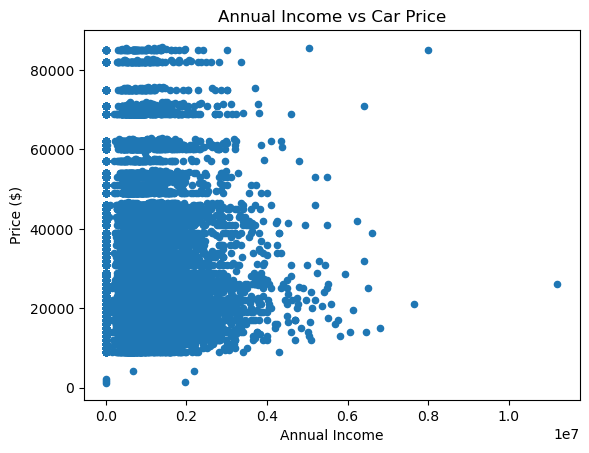

In [37]:
# Import matplotlib
import matplotlib.pyplot as plt

# Create a scatter plot of annual income and car price
car_sales_df.plot.scatter(
    x="Annual Income",
    y="Price ($)"
)

# Add a title
plt.title("Annual Income vs Car Price")

# Display the plot
plt.show()

### 6.1 Numerical-Numerical

### Correlation According To:

#### Pearson

- I used Pearson correlation to check if there is a linear relationship between `Annual Income` and `Price ($)`. The result was **0.0121**, which is almost zero. So there is almost no linear connection between the customer's income and the price of the car.

#### Spearman

- I also checked Spearman correlation, which looks at whether the two variables tend to increase or decrease together based on their ranking. The result was **0.0167**. Since this value is also very close to zero, there is almost no monotonic relationship between income and car price.

#### Kendall

- For Kendall correlation, the result was **0.0114**. This method compares the order of the values between the two variables. Here again, the result is almost zero, so there is almost no relationship between their rankings.

---

### Explain the Difference

- Pearson looks mainly for a linear relationship. Spearman checks if the variables generally move in the same or opposite direction, and Kendall compares the order of the observations. Even though the methods are different, all three gave values very close to zero, so they all point to the same result.

---

### Correlation Matrix

- I created a correlation matrix for `Annual Income` and `Price ($)`. The diagonal values are **1** because each variable is fully correlated with itself. The value between income and car price is **0.0121**, which again shows almost no linear relationship.

---

### Scatter Plots

- In the scatter plot, the points are spread out and there is no clear direction. Customers with higher income do not always buy more expensive cars. This fits the correlation results, which were also very close to zero.

---

### What Conclusions Can Be Drawn About the Correlation?

- All three correlation methods gave values close to zero, and the scatter plot also shows no clear trend. From these results, I do not see a meaningful relationship between `Annual Income` and `Price ($)`. Annual income by itself does not seem to be enough to explain or predict the car price.

## 6. Correlations and Relationships

### 6.2 Categorical-Categorical

In [38]:
# Create a frequency table between company and body style
company_body_style_table = pd.crosstab(
    car_sales_df["Company"],
    car_sales_df["Body Style"]
)

# Display the frequency table
company_body_style_table

Body Style,Hardtop,Hatchback,Passenger,SUV,Sedan
Company,,,,,
Acura,0,269,48,372,0
Audi,70,13,37,348,0
BMW,0,260,0,324,206
Buick,20,212,152,14,41
Cadillac,45,102,232,110,163
Chevrolet,406,318,420,565,110
Chrysler,144,362,37,314,263
Dodge,333,345,216,633,144
Ford,170,434,336,440,234


In [39]:
# Create a frequency table between gender and body style
gender_body_style_table = pd.crosstab(
    car_sales_df["Gender"],
    car_sales_df["Body Style"]
)

# Display the frequency table
gender_body_style_table

Body Style,Hardtop,Hatchback,Passenger,SUV,Sedan
Gender,,,,,
Female,647,1298,883,1335,945
Male,2324,4830,3062,5039,3543


In [40]:
# Create a frequency table between gender and transmission
gender_transmission_table = pd.crosstab(
    car_sales_df["Gender"],
    car_sales_df["Transmission"]
)

# Display the frequency table
gender_transmission_table

Transmission,Auto,Manual
Gender,,
Female,2699,2409
Male,9872,8926


In [41]:
# Create a frequency table between company and transmission
company_transmission_table = pd.crosstab(
    car_sales_df["Company"],
    car_sales_df["Transmission"]
)

# Display the frequency table
company_transmission_table

Transmission,Auto,Manual
Company,,
Acura,293,396
Audi,164,304
BMW,458,332
Buick,285,154
Cadillac,373,279
Chevrolet,772,1047
Chrysler,855,265
Dodge,1048,623
Ford,763,851


In [42]:
# Divide car prices into four price groups
car_sales_df["Price Group"] = pd.qcut(
    car_sales_df["Price ($)"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

# Display the price groups
car_sales_df[["Price ($)", "Price Group"]].head()

,Price ($),Price Group
0,26000,High
1,19000,Medium
2,31500,High
3,14000,Low
4,24500,High


In [43]:
# Create a frequency table between company and price group
company_price_group_table = pd.crosstab(
    car_sales_df["Company"],
    car_sales_df["Price Group"]
)

# Display the frequency table
company_price_group_table

Price Group,Low,Medium,High,Very High
Company,,,,
Acura,242,51,326,70
Audi,227,0,181,60
BMW,254,310,127,99
Buick,71,132,49,187
Cadillac,34,65,245,308
Chevrolet,482,520,411,406
Chrysler,297,336,234,253
Dodge,259,602,497,313
Ford,468,369,280,497


In [44]:
# Create a percentage table within each company
company_price_percentage_table = pd.crosstab(
    car_sales_df["Company"],
    car_sales_df["Price Group"],
    normalize="index"
) * 100

# Round the percentages
company_price_percentage_table = company_price_percentage_table.round(2)

# Display the percentage table
company_price_percentage_table

Price Group,Low,Medium,High,Very High
Company,,,,
Acura,35.12,7.40,47.31,10.16
Audi,48.50,0.00,38.68,12.82
BMW,32.15,39.24,16.08,12.53
Buick,16.17,30.07,11.16,42.60
Cadillac,5.21,9.97,37.58,47.24
Chevrolet,26.50,28.59,22.59,22.32
Chrysler,26.52,30.00,20.89,22.59
Dodge,15.50,36.03,29.74,18.73
Ford,29.00,22.86,17.35,30.79


In [45]:
# Divide annual income into four income groups
car_sales_df["Income Group"] = pd.qcut(
    car_sales_df["Annual Income"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

# Display the income groups
car_sales_df[["Annual Income", "Income Group"]].head()

,Annual Income,Income Group
0,13500,Low
1,1480000,Very High
2,1035000,High
3,13500,Low
4,1465000,Very High


In [46]:
# Create a frequency table between company and income group
company_income_group_table = pd.crosstab(
    car_sales_df["Company"],
    car_sales_df["Income Group"]
)

# Display the frequency table
company_income_group_table

Income Group,Low,Medium,High,Very High
Company,,,,
Acura,171,173,185,160
Audi,112,133,106,117
BMW,197,212,170,211
Buick,107,98,107,127
Cadillac,158,142,143,209
Chevrolet,455,461,489,414
Chrysler,290,275,267,288
Dodge,413,418,430,410
Ford,420,406,380,408


In [47]:
# Create a percentage table within each company
company_income_percentage_table = pd.crosstab(
    car_sales_df["Company"],
    car_sales_df["Income Group"],
    normalize="index"
) * 100

# Round the percentages
company_income_percentage_table = company_income_percentage_table.round(2)

# Display the percentage table
company_income_percentage_table

Income Group,Low,Medium,High,Very High
Company,,,,
Acura,24.82,25.11,26.85,23.22
Audi,23.93,28.42,22.65,25.00
BMW,24.94,26.84,21.52,26.71
Buick,24.37,22.32,24.37,28.93
Cadillac,24.23,21.78,21.93,32.06
Chevrolet,25.01,25.34,26.88,22.76
Chrysler,25.89,24.55,23.84,25.71
Dodge,24.72,25.01,25.73,24.54
Ford,26.02,25.15,23.54,25.28


### 6.2 Categorical-Categorical

### Frequency Tables

- The frequency tables show how often different combinations of two categorical variables appear in the dataset. They make it easier to compare the groups and see which combinations are more common. I used several combinations because each one shows a different part of the data.

  • The table between `Company` and `Body Style` shows how many cars of each body style were sold by each company. For example, if someone is interested in an `SUV`, the table can show which companies had more SUV sales. This gives some information based on what customers actually chose.

  • The table between `Gender` and `Body Style` shows which body styles were purchased by men and women. This could help show which types of cars are more popular in each group and may also be useful for advertising decisions.

  • The table between `Body Style` and `Transmission` shows the transmission types for each body style. I found this table interesting because some of the results were different from what I expected.

  • The table between `Company` and `Transmission` shows which transmission type is more common for each company. It can also be useful when comparing companies and seeing what customers tend to buy from each one.

---

### Find a Relationship Between Categorical and Numerical Variables Using Binning

- The percentage table shows how the price groups are divided within each car company. The results are different between the companies. For example, `Cadillac`, `Buick`, and `Oldsmobile` have a relatively high percentage of cars in the `Very High` group. `Hyundai`, `Subaru`, and `Jaguar` have more cars in the `Medium` group. The `High` group stands out more for `Acura` and `Saab`, while almost half of the `Audi` cars are in the `Low` group. These differences suggest that the company may be related to the price group of the car.

- The annual income table shows the income groups for each car company. For most companies, the four groups are close to 25%, so the distribution is fairly balanced. There are some differences, such as `Cadillac`, where the `Very High` group is about **32.06%**, compared with about **19.44%** for `Jaguar`. Still, no income group clearly stands out for most companies. Because of this, there does not seem to be a strong relationship between annual income and the company of the purchased car.

---

### What Can Be Concluded from the Information?

- The results suggest that the car company is related to the price group, since the price distribution is different between companies. The income groups, on the other hand, are quite similar between companies. So in this dataset, the relationship between company and price level seems clearer than the relationship between customer income and company choice.

## 6. Correlations and Relationships

### 6.3 Graphs

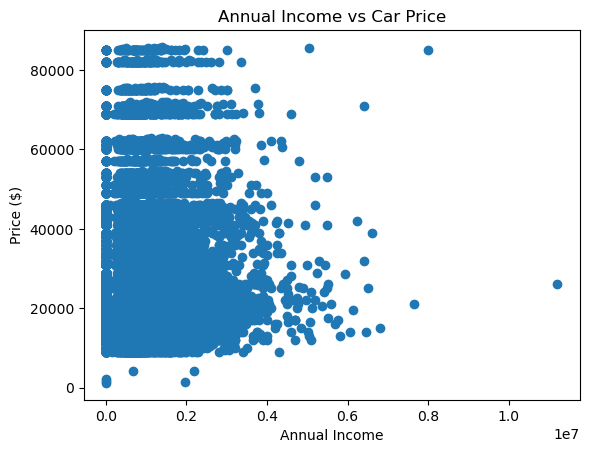

In [48]:
# Import matplotlib
import matplotlib.pyplot as plt

# Create a scatterplot between annual income and car price
plt.scatter(
    car_sales_df["Annual Income"],
    car_sales_df["Price ($)"]
)

# Add a title and axis labels
plt.title("Annual Income vs Car Price")
plt.xlabel("Annual Income")
plt.ylabel("Price ($)")

# Display the scatterplot
plt.show()

### Scatterplot

The scatterplot compares `Annual Income` with `Price ($)`. The points are spread out and there is no clear pattern between the two variables. This also matches the correlation results, which were close to zero. A few very high income values can also be seen in the graph.

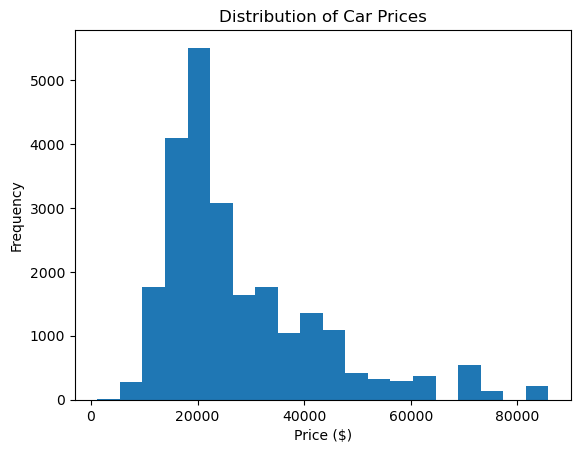

In [49]:
# Histogram

# Create a histogram of car prices
plt.hist(
    car_sales_df["Price ($)"],
    bins=20
)

# Add a title and axis labels
plt.title("Distribution of Car Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")

# Display the histogram
plt.show()

### Histogram

The histogram shows how the car prices are distributed. Most of the cars are priced between about **$15,000 and $30,000**. There are also a few cars with much higher prices, so the distribution has a longer tail on the right side.

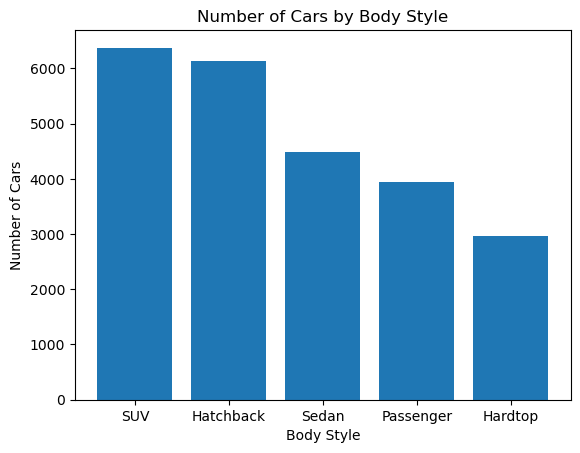

In [50]:
# Barchart

# Count the number of cars in each body style
body_style_counts = car_sales_df["Body Style"].value_counts()

# Create a bar chart
plt.bar(
    body_style_counts.index,
    body_style_counts.values
)

# Add a title and axis labels
plt.title("Number of Cars by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Number of Cars")

# Display the barchart
plt.show()

### Barchart

The bar chart compares the different body styles in the dataset. `SUV` appears the most, with `Hatchback` next. `Hardtop` appears the least compared to the other body styles.

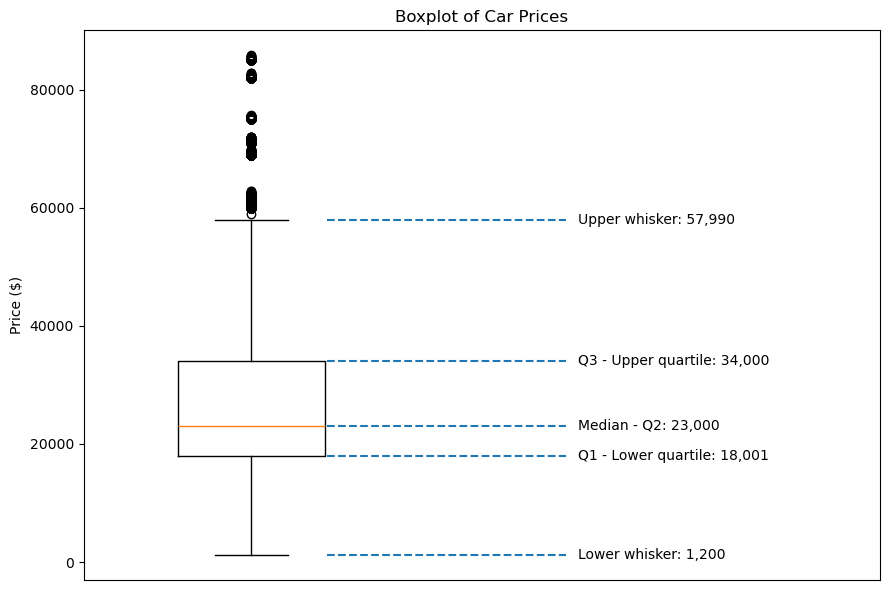

In [51]:
# Boxplot with quartile and whisker labels

# Select the car price data
car_prices = car_sales_df["Price ($)"].dropna()

# Calculate the quartiles
q1 = car_prices.quantile(0.25)
median = car_prices.quantile(0.50)
q3 = car_prices.quantile(0.75)

# Calculate the IQR
iqr = q3 - q1

# Calculate the outlier limits
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# Find the actual whisker values
lower_whisker = car_prices[car_prices >= lower_limit].min()
upper_whisker = car_prices[car_prices <= upper_limit].max()

# Create the boxplot
fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    car_prices,
    widths=0.35
)

# Add dashed lines and labels
boxplot_values = [
    (lower_whisker, "Lower whisker"),
    (q1, "Q1 - Lower quartile"),
    (median, "Median - Q2"),
    (q3, "Q3 - Upper quartile"),
    (upper_whisker, "Upper whisker")
]

for value, label in boxplot_values:
    ax.hlines(
        y=value,
        xmin=1.18,
        xmax=1.75,
        linestyles="dashed"
    )

    ax.text(
        1.78,
        value,
        f"{label}: {value:,.0f}",
        va="center"
    )

# Add a title and axis label
ax.set_title("Boxplot of Car Prices")
ax.set_ylabel("Price ($)")

# Remove the unnecessary x-axis category
ax.set_xticks([])

# Add space for the labels
ax.set_xlim(0.6, 2.5)

# Display the boxplot
plt.tight_layout()
plt.show()

### Boxplot

The boxplot gives a general view of the car price distribution. The line inside the box is the median, and the box itself shows the middle 50% of the prices, between Q1 and Q3. The black circles are values that are outside the 1.5 × IQR range. In this graph, most of these unusual values are on the high-price side, so they appear above the upper whisker.

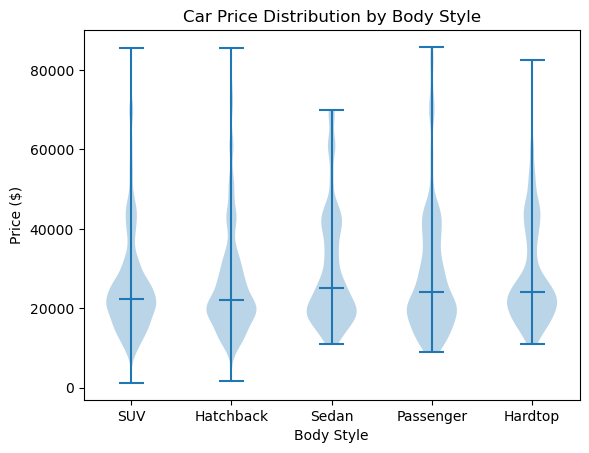

In [52]:
# Violin plot by body style

# Get the body style categories
body_styles = car_sales_df["Body Style"].value_counts().index

# Create a list of car prices for each body style
price_by_body_style = [
    car_sales_df.loc[
        car_sales_df["Body Style"] == body_style,
        "Price ($)"
    ].dropna()
    for body_style in body_styles
]

# Create the violin plot
plt.violinplot(
    price_by_body_style,
    showmedians=True,
    showextrema=True
)

# Add category names to the x-axis
plt.xticks(
    range(1, len(body_styles) + 1),
    body_styles
)

# Add a title and axis labels
plt.title("Car Price Distribution by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price ($)")

# Display the violin plot
plt.show()

### Violin Plot

The violin plot shows how car prices are spread across the different body styles. Most of the prices are around the low and middle ranges. `Sedan` and `Hardtop` seem to have slightly higher prices, while `SUV` and `Hatchback` are more concentrated at lower prices. In every body style, there are also some cars with higher prices.

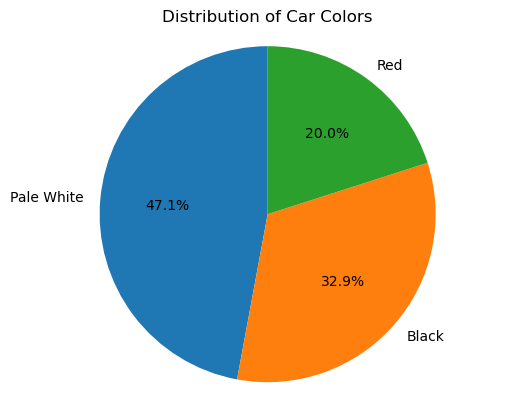

In [53]:
# Pie chart

# Count the number of cars for each color
color_counts = car_sales_df["Color"].value_counts()

# Create the pie chart
plt.pie(
    color_counts.values,
    labels=color_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

# Add a title
plt.title("Distribution of Car Colors")

# Keep the pie chart circular
plt.axis("equal")

# Display the pie chart
plt.show()

### Pie Chart

The pie chart shows how the car colors are divided in the dataset. `Pale White` makes up almost half of the cars, `Black` is around one-third, and `Red` is about one-fifth. So, `Pale White` appears the most, while `Red` appears the least.

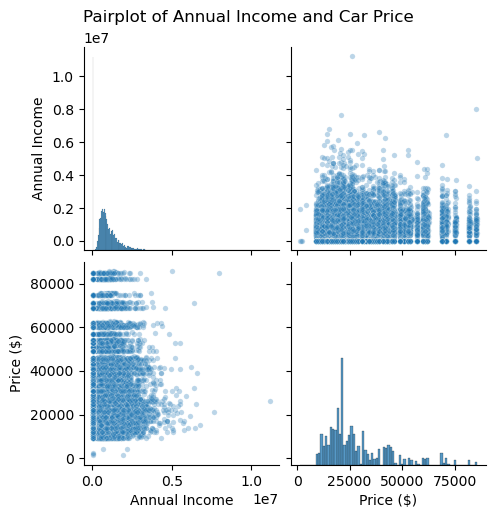

In [54]:
# Import seaborn and matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot

# Select the relevant numerical columns
numerical_data = car_sales_df[
    ["Annual Income", "Price ($)"]
].dropna()

# Create the pairplot
pairplot_graph = sns.pairplot(
    numerical_data,
    diag_kind="hist",
    plot_kws={
        "alpha": 0.3,
        "s": 15
    }
)

# Add a title
pairplot_graph.fig.suptitle(
    "Pairplot of Annual Income and Car Price",
    y=1.02
)

# Display the pairplot
plt.show()

### Pairplot

The pairplot shows `Annual Income` and `Price ($)` together. On the diagonal we can see the distribution of each variable, and in the other graphs we can see the connection between them.

Most of the income values are in the lower and middle ranges, with only a few very high values. For car prices, most of the values are around **$15,000–$30,000**.

From the scatterplots, I do not see a clear connection between income and car price. People with similar incomes bought cars at very different prices, and higher income does not always mean a higher car price. There are also some unusual high values in the data.

In [55]:
# Get the exact price ranges used for the price groups
price_groups, price_bins = pd.qcut(
    car_sales_df["Price ($)"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    retbins=True
)

# Create a table with the price group ranges
price_range_table = pd.DataFrame({
    "Price Group": ["Low", "Medium", "High", "Very High"],
    "Minimum Price ($)": price_bins[:-1],
    "Maximum Price ($)": price_bins[1:]
})

# Round the prices and display the table
price_range_table = price_range_table.round(0)
price_range_table

,Price Group,Minimum Price ($),Maximum Price ($)
0,Low,1200.0,18001.0
1,Medium,18001.0,23000.0
2,High,23000.0,34000.0
3,Very High,34000.0,85800.0


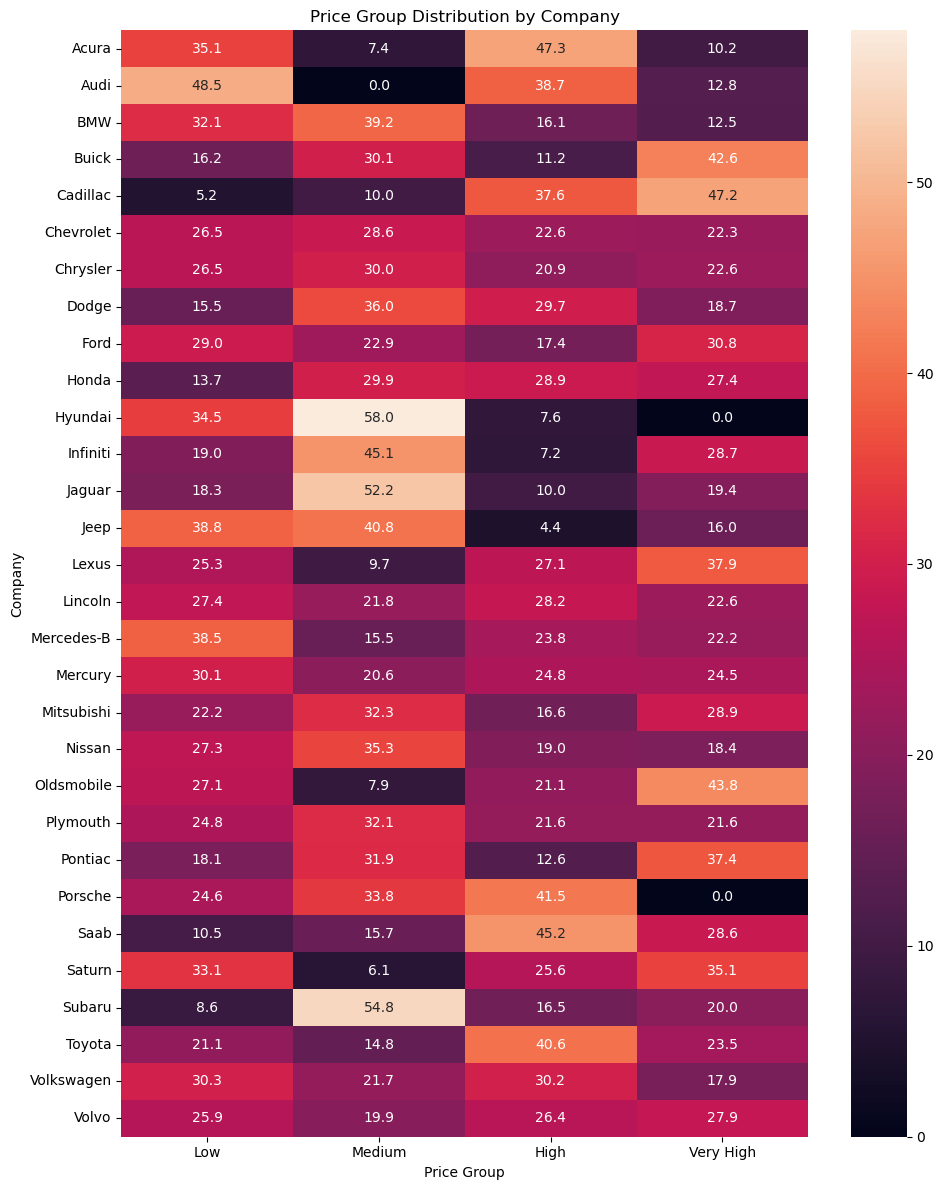

In [56]:
# Heatmap

# Create a heatmap of price group percentages by company
plt.figure(figsize=(10, 12))

sns.heatmap(
    company_price_percentage_table,
    annot=True,
    fmt=".1f"
)

# Add a title and axis labels
plt.title("Price Group Distribution by Company")
plt.xlabel("Price Group")
plt.ylabel("Company")

# Display the heatmap
plt.tight_layout()
plt.show()

### Heatmaps

The heatmap makes it easier to compare the price groups between the different car companies. Some companies have more cars in the higher price groups, while others are more concentrated in the middle or lower groups. For example, `Cadillac` has many cars in `High` and `Very High`, while `Oldsmobile` stands out mainly in `Very High`. On the other hand, `Hyundai` and `Subaru` are more concentrated in the `Medium` group, and almost half of the `Audi` cars are in the `Low` group.

From this graph, it looks like car companies do not have the same price distribution. This may mean that there is some connection between the company and the price group, but the heatmap by itself is not enough to show how strong that connection is.

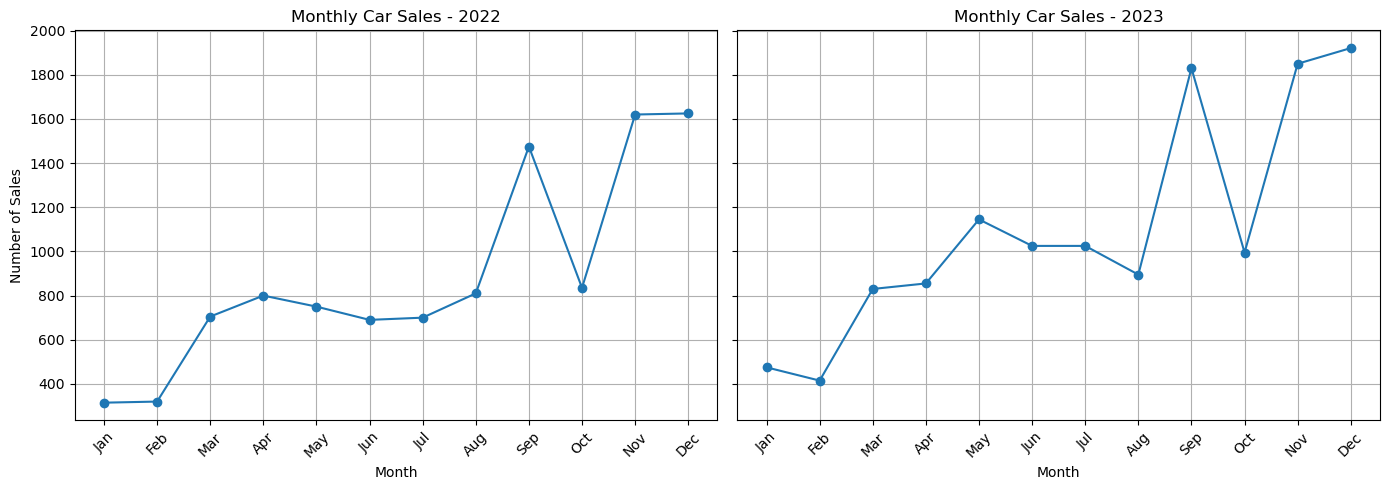

In [57]:
# Import matplotlib
import matplotlib.pyplot as plt

# Convert the Date column to datetime
car_sales_df["Date"] = pd.to_datetime(
    car_sales_df["Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

# Count the number of sales for each year and month
monthly_sales = car_sales_df.groupby(
    [car_sales_df["Date"].dt.year, car_sales_df["Date"].dt.month]
).size()

# Create month names
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Get the monthly sales for 2022
sales_2022 = monthly_sales.loc[2022].reindex(
    range(1, 13),
    fill_value=0
)

# Get the monthly sales for 2023
sales_2023 = monthly_sales.loc[2023].reindex(
    range(1, 13),
    fill_value=0
)

# Create two line graphs
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True
)

# Create the graph for 2022
axes[0].plot(
    months,
    sales_2022.values,
    marker="o"
)

axes[0].set_title("Monthly Car Sales - 2022")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Sales")
axes[0].grid(True)
axes[0].tick_params(axis="x", rotation=45)

# Create the graph for 2023
axes[1].plot(
    months,
    sales_2023.values,
    marker="o"
)

axes[1].set_title("Monthly Car Sales - 2023")
axes[1].set_xlabel("Month")
axes[1].grid(True)
axes[1].tick_params(axis="x", rotation=45)

# Adjust the layout
plt.tight_layout()

# Display the graphs
plt.show()

### Monthly Car Sales Time Series Line Plot

The graphs show the monthly car sales in 2022 and 2023. In both years, sales are lower at the beginning of the year and increase later on.

A clear rise can be seen in September, followed by a drop in October. After that, sales go up again in November and December.

In most months, 2023 has more sales than 2022. Since a similar pattern appears in both years, there may be some seasonal effect on car sales.

## 7. Index Analysis 

In [58]:
# Check whether Car_id can be used as a unique index
print("Number of rows:", len(car_sales_df))
print("Number of unique Car_id values:", car_sales_df["Car_id"].nunique())
print("Number of duplicated Car_id values:", car_sales_df["Car_id"].duplicated().sum())

Number of rows: 23906
Number of unique Car_id values: 23906
Number of duplicated Car_id values: 0


In [59]:
# Convert the Date column to datetime
car_sales_df["Date"] = pd.to_datetime(
    car_sales_df["Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

# Check whether the current index is time-based
print(
    "Is the current index time-based?",
    isinstance(car_sales_df.index, pd.DatetimeIndex)
)

# Display information about the Date column
print("Date column type:", car_sales_df["Date"].dtype)
print("First date:", car_sales_df["Date"].min())
print("Last date:", car_sales_df["Date"].max())
print("Number of unique dates:", car_sales_df["Date"].nunique())
print("Number of repeated date values:", car_sales_df["Date"].duplicated().sum())

Is the current index time-based? False
Date column type: datetime64[ns]
First date: 2022-01-02 00:00:00
Last date: 2023-12-31 00:00:00
Number of unique dates: 612
Number of repeated date values: 23294


In [60]:
# Check whether the dates are sorted in ascending order
print(
    "Is the Date column sorted?",
    car_sales_df["Date"].is_monotonic_increasing
)

# Check whether Car_id is sorted in ascending order
print(
    "Is Car_id sorted?",
    car_sales_df["Car_id"].is_monotonic_increasing
)

Is the Date column sorted? True
Is Car_id sorted? True


## 7. Index Analysis

- The table currently uses a `RangeIndex` that pandas created automatically. It is unique, but it only gives a number to each row. The `Car_id` column is more useful as a logical ID because every sale has its own value. There are 23,906 unique `Car_id` values, with no duplicates and no missing values.

- The index itself is not based on time. The dates are stored in the `Date` column, which was converted to `datetime`. The dataset includes sales from January 2, 2022, until December 31, 2023, with 612 different dates. Since more than one sale can happen on the same day, the `Date` column has repeated values and cannot be used alone as a unique index.

- Sales are not the same throughout the period. From the monthly graphs, sales are usually lower at the beginning of the year and higher in some of the later months. In most months, 2023 also has more sales than 2022. So the results do change over time, and there seems to be a monthly pattern.

- The `Date` column is sorted from earlier to later dates, and `Car_id` is also sorted in increasing order. This means the data is already organized in a way that makes it easier to follow the sales over time.

## 8. Insights and the Data Story

### Main Insights

#### 1. There Is No Meaningful Relationship Between Annual Income and Car Price

The three correlation tests gave values that were very close to zero. I also did not see any clear trend in the scatterplot. Because of this, it seems that annual income by itself does not really explain how much a customer paid for a car.

#### 2. The Car Company Is Related to the Price Level

When I compared the price groups between the different companies, I noticed that they were not distributed in the same way. Some companies had more cars in the higher price groups, while others had more cars in the low and medium groups. This shows that the company seems to have some connection with the price level of the car.

#### 3. The Number of Sales Changes Over Time

The monthly sales were different throughout the year. Sales were usually lower at the beginning of the year, and in some of the later months they increased. I also noticed that in most months, 2023 had more sales than 2022. Since there is a similar pattern in both years, there may be some seasonal effect on car sales.

---

### Possible Bias

One possible bias in the dataset is the difference between the number of men and women. About **78.6%** of the customers are men and only about **21.4%** are women.

Because the female group is much smaller, comparisons between men and women may not give a completely balanced picture. This also means that the dataset may not represent all car buyers in the same way.

---

### Possible Failure Points for Engineering and Statistical Uses

- While working with the data, I noticed that some useful information is missing, such as car year, mileage, condition, and equipment level. Without these details, it is harder to understand what really affects the car price.

- There are some unusual high values in both annual income and car price. These values can affect calculations such as the mean and correlation.

- Some groups have many more records than others. For example, there are many more men than women, and some companies or models have only a small number of sales. Because of this, results from smaller groups may be less reliable.

- In some parts of the analysis, I divided income and price into groups. The results can depend on how these groups are divided, so using different limits could give slightly different results.

- Seeing a connection between two variables does not mean that one of them caused the other. There could be another variable that is missing from the dataset and affects both.

---

### What Did I Learn from the Analysis? Did My Opinion Change?

One thing I learned from this analysis is that looking only at the mean is not enough. The median, distribution, outliers, and graphs can give a much better picture of what is happening in the data. I also noticed that sometimes a graph makes a result much easier to understand than a table.

Before doing the analysis, I expected customers with higher income to buy more expensive cars. I was surprised that the correlation tests showed almost no connection between annual income and car price. This was different from what I expected before starting the analysis.

Another thing that surprised me was the percentage of manual transmission cars among women. I expected this percentage to be lower, so this result did not really match the assumption I had before looking at the data.

Some of my other ideas were actually supported by the results. For example, different car companies had different price distributions, so the company seems to have some connection with the price level.

I also saw that most cars are in the low and medium price ranges, while only a smaller number are very expensive.

`SUV` and `Hatchback` were the most common body styles in the dataset. I also noticed a similar sales pattern in 2022 and 2023, which made me think that car sales may have some seasonal behavior.

## 9. Bonus

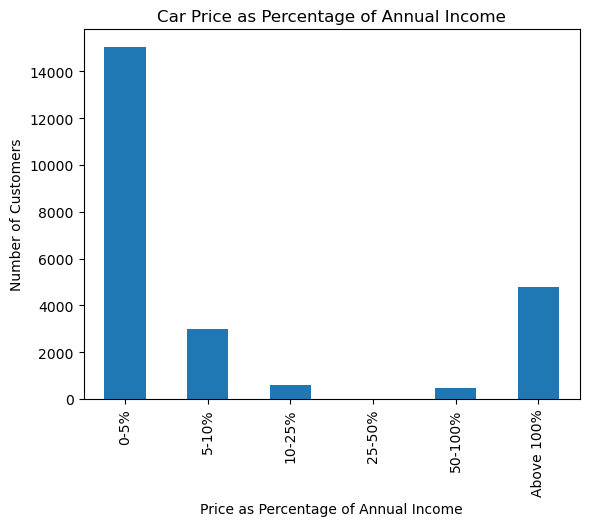

In [61]:
# Feature Engineering: car price as a percentage of annual income
car_sales_df["Price_to_Income_Percent"] = (
    car_sales_df["Price ($)"] / car_sales_df["Annual Income"]
) * 100

# Divide the new feature into groups
car_sales_df["Price_to_Income_Group"] = pd.cut(
    car_sales_df["Price_to_Income_Percent"],
    bins=[0, 5, 10, 25, 50, 100, float("inf")],
    labels=[
        "0-5%",
        "5-10%",
        "10-25%",
        "25-50%",
        "50-100%",
        "Above 100%"
    ]
)

# Count the customers in each group
price_income_groups = car_sales_df[
    "Price_to_Income_Group"
].value_counts(sort=False)

# Create a bar chart
price_income_groups.plot(kind="bar")

# Add a title and axis labels
plt.title("Car Price as Percentage of Annual Income")
plt.xlabel("Price as Percentage of Annual Income")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

In [62]:
# Hypothesis Testing
from scipy.stats import ttest_ind

# Get car prices for male and female customers
male_prices = car_sales_df[
    car_sales_df["Gender"] == "Male"
]["Price ($)"]

female_prices = car_sales_df[
    car_sales_df["Gender"] == "Female"
]["Price ($)"]

# Perform Welch's t-test
t_stat, p_value = ttest_ind(
    male_prices,
    female_prices,
    equal_var=False
)

# Display the results
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.0013600324721355
P-value: 0.3166834138864709


## 9. Bonus

### Time Dependency

Toward the end of the year, especially in November and December, the number of sales goes up. One possible reason is that dealerships may offer more deals at this time and try to sell older stock before the new model year starts.

This could encourage some customers to buy a car during these months. Still, the dataset does not include information about discounts, promotions, inventory, or model year, so I cannot say that this is definitely the reason. It is only one possible explanation that matches the pattern in the graphs.

---

### Feature Engineering

I created a new variable that compares the car price with the customer's annual income.

The calculation is:

`Car Price / Annual Income × 100`

The result shows how much of the annual income is represented by the car price.

I divided the values into groups so the result would be easier to read.

Most customers are in the `0-5%` group, which means that for most of them the car price is only a small part of their annual income.

There is also a noticeable group in `Above 100%`. For these customers, the car price is higher than the annual income value that appears in the dataset.

---

### Hypothesis Testing

I checked whether there is a difference in the average car price between male and female customers.

- H0: There is no difference in the average car price between males and females.
- H1: There is a difference in the average car price between males and females.

I used Welch's t-test because the two groups are different in size.

The p-value from the test was **0.3167**.

Since this value is higher than 0.05, I do not reject H0.

Based on this test, there is no statistically significant difference in the average car price between male and female customers.

---

### Suggestions for Further Research

- It would be useful to add information such as car year, mileage, and equipment level to better understand what affects the car price.

- It would also be useful to use data from more years and check if the increase in sales near the end of the year happens again and is really a seasonal pattern.